# MLP House Price Regression – Zero Data Leakage

## File Overview
This notebook trains a **simple MLP with an uncompromising focus on preventing data leakage**. Every preprocessing step (imputation, encoding, scaling) is fitted **exclusively on the training set** and then applied to validation and test data.

## Key Characteristics
- **Data Split:** Chronological 90% train / 10% validation (time‑based hold‑out).  
- **Leakage Prevention:** Missing value medians, label encoders, and scaler are derived **only from training data**; unseen categories are mapped to -1.  
- **Model:** 3‑layer MLP (128 → 64 → 32) with Dropout and early stopping.  
- **Evaluation:** MAE, RMSE, R² on validation and unseen test data.  
- **Optional SHAP:** Commented‑out section for PermutationExplainer.  

## Use Case
Choose this notebook as a **clean, production‑ready template** where avoiding future information leakage is the highest priority.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from pathlib import Path

# Force deterministic operations (optional, for GPU consistency)
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
tf.config.experimental.enable_op_determinism()

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

 ## 1. Load Data

In [ ]:
BASE_DIR = Path.cwd()                     # notebook folder
TRAIN_PATH = BASE_DIR.parent.parent / "data" / "TRAIN.csv"
TEST_PATH = BASE_DIR.parent.parent / "data" / "TEST.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(TRAIN_PATH)
print("Training data shape:", df.shape)
df.head()

df.info()
print("\nMissing values:\n", df.isnull().sum())

Training data shape: (165808, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165808 entries, 0 to 165807
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   City              165808 non-null  object 
 1   Reg               165808 non-null  object 
 2   Dist              165808 non-null  object 
 3   Neigh             165808 non-null  object 
 4   Tran_Dt           165808 non-null  object 
 5   Tran_Day          165808 non-null  int64  
 6   Tran_Pri          165808 non-null  int64  
 7   Layout            165808 non-null  object 
 8   Prop_Flo          165808 non-null  object 
 9   Tot_Flo           165808 non-null  float64
 10  Flo_Area          165808 non-null  float64
 11  Build_Type        165808 non-null  object 
 12  Orient            165808 non-null  object 
 13  Build_Yr          105708 non-null  float64
 14  ReNov             165808 non-null  object 
 15  Build_Str         165808 non-null 

## 2. Feature Engineering (No Leakage – Done on Full Data for Now, Split Comes Next)


In [ ]:
data = df.copy()

# Parse date
data['Tran_Dt'] = pd.to_datetime(data['Tran_Dt'], format='%Y.%m.%d')
data['Tran_Year'] = data['Tran_Dt'].dt.year
data['Tran_Month'] = data['Tran_Dt'].dt.month
data['Tran_Day_of_Month'] = data['Tran_Dt'].dt.day

# Combine Build_Yr_Filled and Build_Yr
data['Build_Yr'] = data['Build_Yr_Filled'].combine_first(data['Build_Yr'])
data.drop('Build_Yr_Filled', axis=1, inplace=True)
data['Build_Yr'] = pd.to_numeric(data['Build_Yr'], errors='coerce')

# Parse EA_Ratio
def parse_ea_ratio(ratio_str):
    if pd.isna(ratio_str) or ratio_str == '':
        return np.nan
    import re
    match = re.match(r'(\d+)E(\d+)A', str(ratio_str))
    if match:
        elevators = int(match.group(1))
        apartments = int(match.group(2))
        return elevators / apartments if apartments != 0 else 0
    return np.nan

data['EA_Ratio_Num'] = data['EA_Ratio'].apply(parse_ea_ratio)
data.drop('EA_Ratio', axis=1, inplace=True)

# Drop constant column
data.drop('City', axis=1, inplace=True)

# Separate target
target = 'Tran_Pri'
y = data[target]
X = data.drop(target, axis=1)

print("Features shape:", X.shape)

Features shape: (165808, 23)


## 3. Time‑Based Split (90% Train, 10% Validation – Chronological Order)


In [10]:
# Sort by transaction date (already a datetime column)
data_sorted = data.sort_values('Tran_Dt').reset_index(drop=True)
split_idx = int(len(data_sorted) * 0.9)
train_df = data_sorted.iloc[:split_idx].copy()
val_df = data_sorted.iloc[split_idx:].copy()

y_train = train_df[target]
X_train = train_df.drop(columns=[target, 'Tran_Dt'])
y_val = val_df[target]
X_val = val_df.drop(columns=[target, 'Tran_Dt'])

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 149227
Validation samples: 16581


## 4. Impute Missing Values Using Only Training Data


In [11]:
# Build_Yr
train_median_build_yr = X_train['Build_Yr'].median()
X_train['Build_Yr'] = X_train['Build_Yr'].fillna(train_median_build_yr)
X_val['Build_Yr'] = X_val['Build_Yr'].fillna(train_median_build_yr)

# EA_Ratio_Num
train_median_ea = X_train['EA_Ratio_Num'].median()
X_train['EA_Ratio_Num'] = X_train['EA_Ratio_Num'].fillna(train_median_ea)
X_val['EA_Ratio_Num'] = X_val['EA_Ratio_Num'].fillna(train_median_ea)

assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum() == 0

## 5. Encode Categorical Variables (Fit on Training Only)


In [12]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Unseen categories in validation -> -1
    X_val[col] = X_val[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    label_encoders[col] = le

# No missing values after encoding
assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum() == 0

Categorical columns: ['Reg', 'Dist', 'Neigh', 'Layout', 'Prop_Flo', 'Build_Type', 'Orient', 'ReNov', 'Build_Str', 'Lift', 'Prop_Type', 'Build_Pur']


## 6. Scale Features (Fit on Training Only)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [17]:
# Take first 80% of training data (chronologically) for training, last 20% for internal validation
split_idx_internal = int(len(X_train_scaled) * 0.8)
X_train_final = X_train_scaled[:split_idx_internal]
y_train_final = y_train.iloc[:split_idx_internal]
X_val_internal = X_train_scaled[split_idx_internal:]
y_val_internal = y_train.iloc[split_idx_internal:]

print(f"Internal training samples: {X_train_final.shape[0]}")
print(f"Internal validation samples: {X_val_internal.shape[0]}")

Internal training samples: 119381
Internal validation samples: 29846


## 7. Build MLP Model

In [18]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(X_train_scaled.shape[1])
model.summary()

C:\Users\Neysa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train with Early Stopping

In [19]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_internal, y_val_internal),         # 20% of training set used as internal validation
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 1829543.6250 - mae: 893.4456 - val_loss: 2476235.5000 - val_mae: 975.4520
Epoch 2/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1588138.5000 - mae: 827.5691 - val_loss: 2458260.7500 - val_mae: 972.5079
Epoch 3/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1574342.5000 - mae: 821.7252 - val_loss: 2448912.0000 - val_mae: 961.7794
Epoch 4/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1591296.0000 - mae: 817.3818 - val_loss: 2436640.5000 - val_mae: 957.6130
Epoch 5/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1561548.6250 - mae: 814.8838 - val_loss: 2434664.0000 - val_mae: 959.0226
Epoch 6/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1565715.1250 - mae: 813.6544 - val_loss: 2424068.2500 - val_mae: 953.6707
Epoch 7/150
3731/3731 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1558490.1250 - mae: 811.3499 - val_loss: 2421404.2500 - val_mae: 955.8735
Epoch 8/150
3731/3731 ━━━━━━━━━━━━━━━━━

## 9. Plot Training Curves


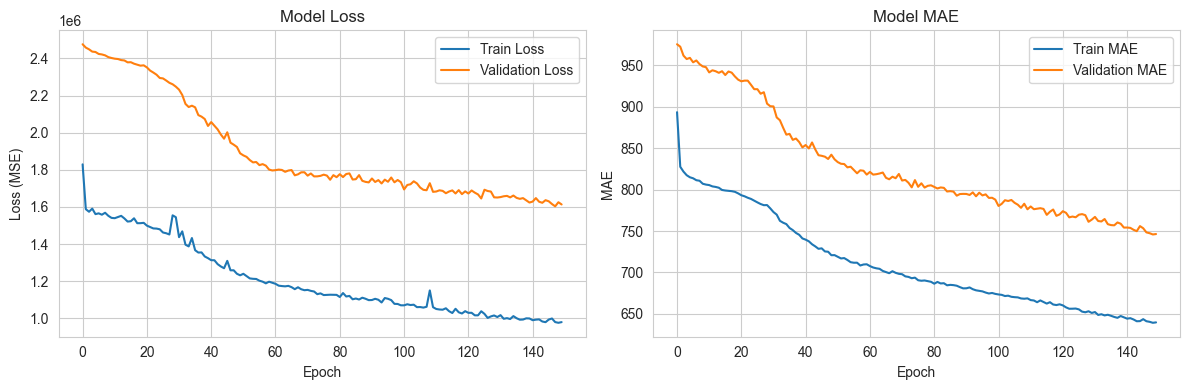

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Model MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on Validation Set (Time‑Based Holdout)

519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation MAE  : 760.65
Validation RMSE : 1269.41
Validation R²   : 0.5091


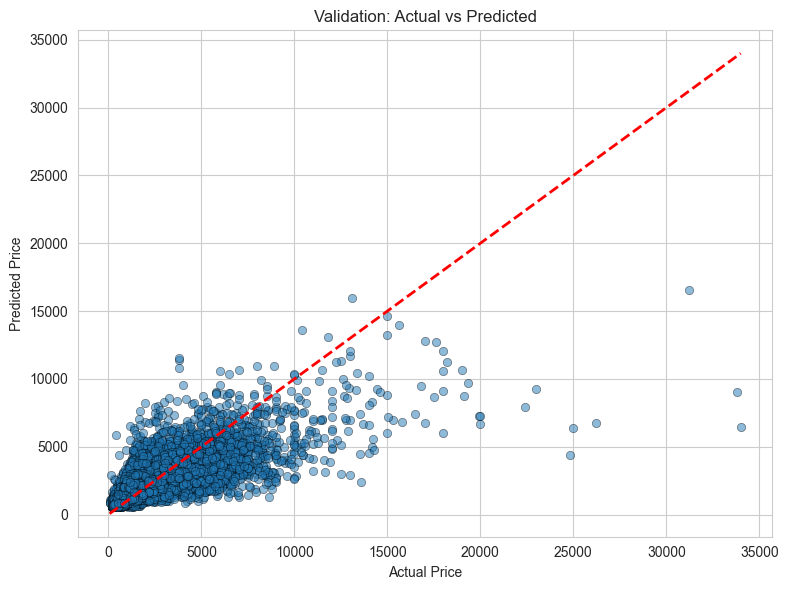

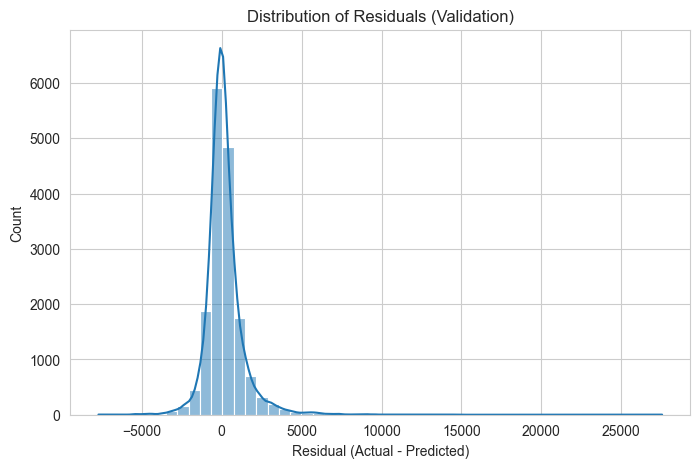

In [21]:
y_pred_val = model.predict(X_val_scaled).flatten()

mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print(f"Validation MAE  : {mae_val:.2f}")
print(f"Validation RMSE : {rmse_val:.2f}")
print(f"Validation R²   : {r2_val:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Validation: Actual vs Predicted')
plt.tight_layout()
plt.show()

residuals = y_val - y_pred_val
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50)
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Distribution of Residuals (Validation)')
plt.show()

## 11. Save Model and Preprocessors for Future Use


In [23]:
import joblib
model.save(OUTPUT_DIR / 'real_estate_price_model.keras')
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
joblib.dump(label_encoders, OUTPUT_DIR / 'label_encoders.pkl')
print("Model and preprocessing objects saved.")

Model and preprocessing objects saved.


## 12. Evaluate on Unseen Test Data (No Leakage)

Test dataset shape: (62733, 23)


C:\Users\Neysa\AppData\Local\Temp\ipykernel_25432\2602610623.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Build_Yr'].fillna(train_median_build_yr, inplace=True)
C:\Users\Neysa\AppData\Local\Temp\ipykernel_25432\2602610623.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

Test features shape after preprocessing: (62733, 22)
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

=== Performance on Unseen Test Data ===
MAE  : 769.29
RMSE : 1362.89
R²   : 0.5059


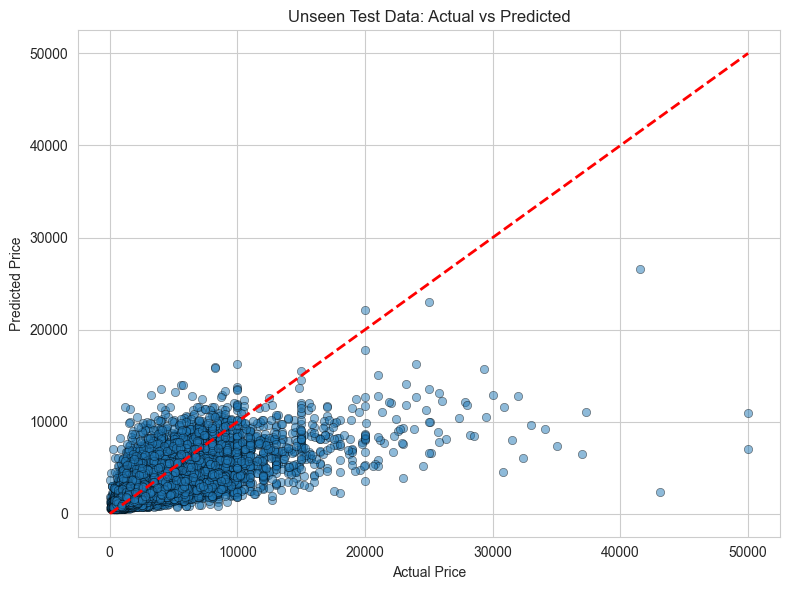

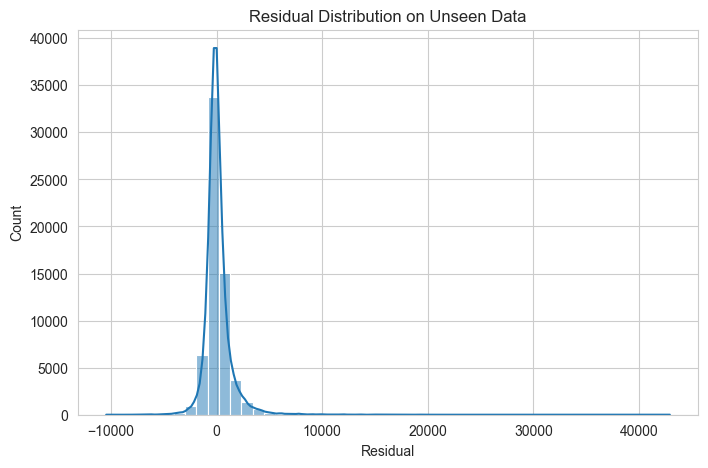

In [24]:
df_test = pd.read_csv(TEST_PATH)
print("Test dataset shape:", df_test.shape)
df_test.head()

# %% [code]
test_data = df_test.copy()

# Same feature engineering steps
test_data['Tran_Dt'] = pd.to_datetime(test_data['Tran_Dt'], format='%Y.%m.%d')
test_data['Tran_Year'] = test_data['Tran_Dt'].dt.year
test_data['Tran_Month'] = test_data['Tran_Dt'].dt.month
test_data['Tran_Day_of_Month'] = test_data['Tran_Dt'].dt.day
test_data.drop('Tran_Dt', axis=1, inplace=True)

test_data['Build_Yr'] = test_data['Build_Yr_Filled'].combine_first(test_data['Build_Yr'])
test_data.drop('Build_Yr_Filled', axis=1, inplace=True)
test_data['Build_Yr'] = pd.to_numeric(test_data['Build_Yr'], errors='coerce')
test_data['Build_Yr'].fillna(train_median_build_yr, inplace=True)

test_data['EA_Ratio_Num'] = test_data['EA_Ratio'].apply(parse_ea_ratio)
test_data['EA_Ratio_Num'].fillna(train_median_ea, inplace=True)
test_data.drop('EA_Ratio', axis=1, inplace=True)

test_data.drop('City', axis=1, inplace=True)

# Separate target if present
if 'Tran_Pri' in test_data.columns:
    y_test = test_data['Tran_Pri']
    X_test = test_data.drop('Tran_Pri', axis=1)
else:
    y_test = None
    X_test = test_data

# Encode categoricals using fitted label encoders
for col in cat_cols:
    le = label_encoders[col]
    X_test[col] = X_test[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

# Scale using fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Test features shape after preprocessing:", X_test_scaled.shape)

# 
if y_test is not None:
    y_pred_test = model.predict(X_test_scaled).flatten()
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    print("\n=== Performance on Unseen Test Data ===")
    print(f"MAE  : {mae_test:.2f}")
    print(f"RMSE : {rmse_test:.2f}")
    print(f"R²   : {r2_test:.4f}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='k', linewidth=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Unseen Test Data: Actual vs Predicted')
    plt.tight_layout()
    plt.show()
    
    residuals_test = y_test - y_pred_test
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals_test, kde=True, bins=50)
    plt.xlabel('Residual')
    plt.title('Residual Distribution on Unseen Data')
    plt.show()
else:
    print("No target column in test file – predictions only.")
    y_pred_test = model.predict(X_test_scaled).flatten()
    print("First 10 predictions:", y_pred_test[:10])

## 13. (Optional) SHAP Feature Importance – No Leakage Sample

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   0%|          | 1/300 [00:00<?, ?it/s]

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:   1%|          | 3/300 [00:19<08:21,  1.69s/it]

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer: 100%|█████████▉| 299/300 [19:08<00:03,  3.35s/it]

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 300/300 [19:12<00:00,  3.34s/it]

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer: 301it [19:15,  3.85s/it]                         


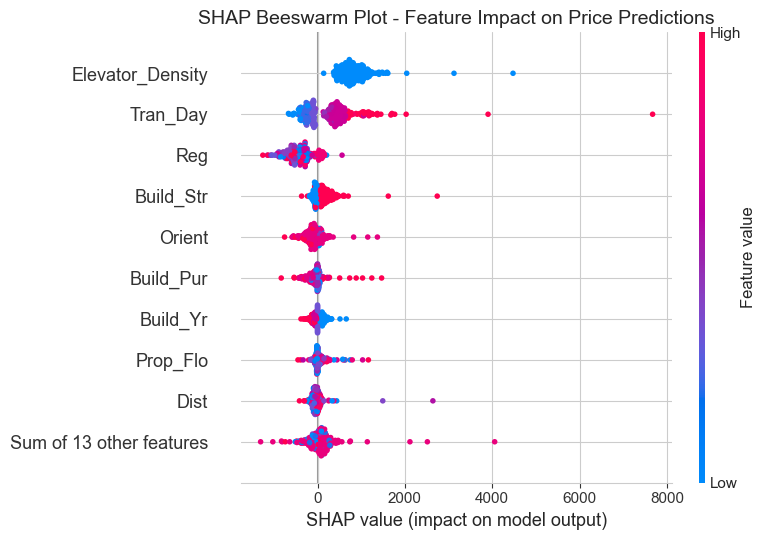

In [ ]:
# Uncomment if shap is installed and you want to analyze feature importance.
import shap
import warnings
warnings.filterwarnings('ignore')

sample_size = min(300, X_test_scaled.shape[0])
X_sample = X_test_scaled[:sample_size]
background = X_train_scaled[:100]

explainer = shap.Explainer(model.predict, background, feature_names=X.columns.tolist())
shap_values = explainer(X_sample, max_evals=500)


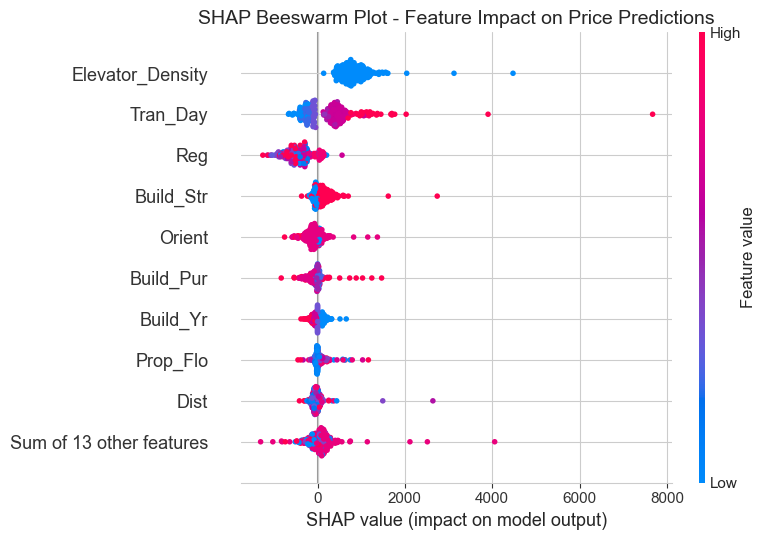

In [27]:
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Beeswarm Plot - Feature Impact on Price Predictions', fontsize=14)
plt.savefig(OUTPUT_DIR / 'SHAP Beeswarm Plot.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()